In [6]:
import numpy as np
import os, sys 
import re
import ROOT
ROOT.gStyle.SetOptStat(0)
import array
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import glob
import pandas as pd

import matplotlib.pyplot as plt
from linearization import linearization
import read_relcal
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
from ROOplot import ROOplot

Welcome to JupyROOT 6.28/10


In [7]:
config_path = "/sdf/home/p/perrywar/cdmsbats_config/UserSettings/BatRootSettings/analysis/"
config_sim = "DMCData.HV100mm_uni_triangle"
config_data = "configCUTEData.NxM.50VZ1Z30VZ6.V4.0.0"
relcal_path = {'K':  config_path+config_sim,
               'L':  config_path+config_sim,
               'Pb':  config_path+config_sim,
               'data': config_path+config_data}

det     = {'sim': 1, 'L': 1, 'K': 1, 'Pb': 1, 'data': 1}
trigdet = {'sim': 0, 'L': 0, 'K': 0, 'Pb': 0, 'data': 1}

In [8]:
## R37 Z1 low bg 50V
series_list=['23240109_075338', '23240109_021236', '23240108_203134', '23231221_101235', '23231221_015705', '23231220_190923', '23231220_122140', 
             '23231220_053358', '23231220_012745', '23231219_184002', '23231219_110331', '23231219_034952', '23231218_223530', '23231218_190035', 
             '23231218_152721', '23231218_093255', '23231218_024511', '23231217_212512', '23231217_171613', '23231217_135018', '23231216_233807', 
             '23231216_211119', '23231216_194929', '23231216_182937', '23231216_173436', '23231216_145300', '23231216_100125', '23231216_043946', 
             '23231216_013604']
ProdTag = 'CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6'

In [9]:
chan_let = ["A", "B", "C", "D", "E", "F"]
channels = [f"P{letter}S{side}" for side in [1, 2] for letter in ["A", "B", "C", "D", "E", "F"]]
RQ_branches = (["PTOFamps", "PTOFchisqLF", "PTOFdelay", "EventTriggerID"] + 
               [chan + "OFamps" for chan in channels] + 
               [chan + "OFchisqLF" for chan in channels] + 
               [chan + "OFdelay" for chan in channels])
DMC_branches = ["EventNum", "X", "Y", "Z", "trueEnergy"]
keVt2keVee = 1/(1 + 50/3) # inverse of Luke gain factor
lin2keVee = {'sim': 210e2 * keVt2keVee, 'data': 210e2 * keVt2keVee} # (keVt/linAmp) * (keVee / keVt)

## Load in data RQs

In [10]:
## Use DataCat to pull the series
dc = CDMSDataCatalog().findData(
    Facility    = "CUTE",
    nFridgeRun  = 37,
    Series      = series_list,
    ProdTag     = ProdTag,
    nMergeLevel = 1,
    dofetch     = True
)
RQfiles_data = [x.filePath for x in dc]

In [11]:
df = {}

## load relevant RQs for data
RQs = CDataFrame("rqDir/zip"+str(det["data"]), RQfiles_data, friends = [[x+":rqDir/eventTree" for x in RQfiles_data]])
    
## Apply some basic data quality filters and get the RQs you're interested in
RQs_filtered = RQs.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(trigdet["data"]), "PTOFamps>0"])
df["data"] = RQs_filtered.AsNumpy(RQ_branches)

## linearize and calibrate PTOFamps to keVee
lin_class = linearization(det["data"], 'PTOFamps', 'unbinned')
df["data"]['lin_PTOFamps'] = lin_class.linearize(df["data"]['PTOFamps'])
df["data"]['calib_PTOFamps'] = df["data"]['lin_PTOFamps'] * lin2keVee["data"]

## Load in DMC hits and RQs

In [12]:
fp = "/sdf/data/supercdms/workarea/simulations/wperry/" ## this is the global file path the DMC data is saved in on s3df

## Define the filepaths used
samples = {"L": "Ge71_Lshell_pos50V_V05-09",
           "K": "Ge71_Kshell_pos50V_100kEvents_V05-09",
           "Pb": "HV100mm_Pb210_50V"}
truth =   {"L": "/DMCOutput/*.root",
           "K": "/DMCOutput/R*/*.root",
           "Pb": "/DMCOutput/*.root"}
proc =    {"L": "/Processed/Unmerged/*/*.root",
           "K": "/Processed_fixedTemplates/R*/Unmerged/*/*.root",
           "Pb": "/Processed/Unmerged/*/*.root"}

In [13]:
sample_names = list(samples.keys())

## Get the file names in these folders
RQfiles = {s: np.sort(glob.glob(fp+samples[s]+proc[s])) for s in sample_names}
truthfiles = {s: np.sort(glob.glob(fp+samples[s]+truth[s])) for s in sample_names}

 ## load relevant truth parameters
DMChits = {s: pd.DataFrame(CDataFrame("G4SimDir/g4dmcHits", truthfiles[s]).AsNumpy(DMC_branches)) for s in sample_names}

## Combine hits in multi-hit sample
DMChits['Pb'] = (
    DMChits['Pb']
    .groupby("EventNum", as_index=False)
    .agg(
        X=("X", "mean"),
        Y=("Y", "mean"),
        Z=("Z", "mean"),
        trueEnergy=("trueEnergy", "sum"),
    )
)

## load relevant RQs
filters = ["TriggerType == 1", "TriggerDetectorNum=="+str(trigdet["sim"]), "PTOFamps>0"]
RQs = {s: pd.DataFrame(CDataFrame("rqDir/zip"+str(det["sim"]), RQfiles[s], 
                          friends = [[x+":rqDir/eventTree" for x in RQfiles[s]]]).Filters(filters).AsNumpy(RQ_branches)) for s in sample_names}

for s in sample_names:
    
    ## deal with CDMSSIM-451
    for branch in channels + ['PT']:
        RQs[s][branch + 'OFamps'] *= 10/4
        
    ## combine truth and RQ information by matching event number
    DMChits[s] = DMChits[s].rename(columns={'EventNum': 'EventTriggerID'})
    df[s] = pd.merge(RQs[s], DMChits[s], on='EventTriggerID', how='inner')
    df[s]['R'] = np.sqrt(df[s]['X']**2 + df[s]['Y']**2)
    
    ## linearize and calibrate PTOFamps to keVee
    lin_class = linearization(det["sim"], 'PTOFamps', 'unbinned')
    df[s]['lin_PTOFamps'] = lin_class.linearize(df[s]['PTOFamps'])
    df[s]['calib_PTOFamps'] = df[s]['lin_PTOFamps'] * lin2keVee["sim"]

## Defining new quantities for all samples

In [14]:
for s in ['data']+sample_names:
    rel_calibs = read_relcal.get_rel_calib(relcal_path[s])
    for chan in channels:
        df[s][chan+'OFamps'] *= rel_calibs[det[s]][chan]
    
    df[s]['E_sum'] = np.array([sum([df[s][chan+'OFamps'][i] for chan in channels]) for i in range(len(df[s]['PTOFamps']))])
    
    for chan in chan_let:
        df[s][chan] = (df[s][f'P{chan}S1OFamps'] + df[s][f'P{chan}S2OFamps']) / df[s]['PTOFamps']
    df[s]['CDE'] = df[s]['C'] + df[s]['D'] + df[s]['E']
    df[s]['RadialPar'] = df[s]['F'] - df[s]['A']
    
    if s=='data': continue
    df[s] = df[s].to_dict(orient='list')
    for key in list(df[s].keys()):
        df[s][key] = np.array(df[s][key])

In [15]:
df['Ge'] = {}
K_prob, L_prob = 87.57, 10.53
L_stat = len(df['L']['EventTriggerID'])
for key in list(df['K'].keys()):
    df['Ge'][key] = np.concatenate([df['L'][key], df['K'][key][:int((K_prob/L_prob)*L_stat)]])

In [16]:
baseline_res = 129.2*1e-3 # keVee
for s in ['data','Ge']+sample_names:
    df[s]['cut']  = (df[s]['calib_PTOFamps'] < 14) & (df[s]['calib_PTOFamps'] > 7*baseline_res)

In [17]:
## Set of cuts for selecting events in different regions of the Ge-71 spectrum. Bounds often set by the +/-3 sigma edges of the peaks. 
##Fit results taken from here:
# https://confluence.slac.stanford.edu/spaces/CDMS/pages/601696559/Comparing+Ge+activation+rates+in+data+and+simulation
bounds = {'sim': {'K': {'lower': 9.9632 - 3*0.1209,
                        'upper': 9.9632 + 3*0.1209},
                  'L': {'lower': 1.2512 - 3*0.0240,
                        'upper': 1.2512 + 3*0.0240}},
          'data':{'K': {'lower': 10.08 - 3*0.23,
                        'upper': 10.63 + 3*0.2},
                  'L': {'lower': 1.280 - 3*0.063,
                        'upper': 1.280 + 3*0.063}}}

## Events inside +/- 3 sigma of the K shell peak.
for s in ['data', 'Ge', 'Pb']:
    key = 'data' if s=='data' else 'sim'
    df[s]['Kshell_cut'] = (df[s]['calib_PTOFamps'] < bounds[key]['K']['upper']) & (df[s]['calib_PTOFamps'] > bounds[key]['K']['lower'])
    df[s]['BG_cut'] = (df[s]['calib_PTOFamps'] < bounds[key]['K']['lower']) & (df[s]['calib_PTOFamps'] > bounds[key]['L']['upper'])

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


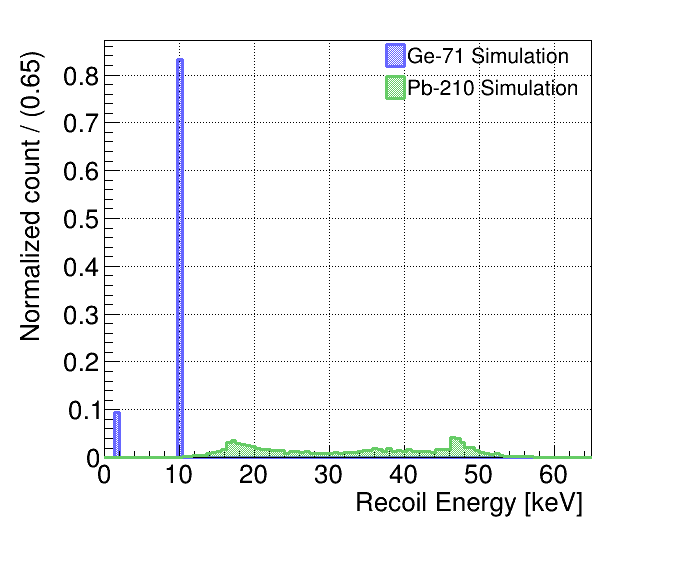

In [18]:
bins_start, bins_end, nbins = 0, 65, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

plt = ROOplot(_xlabel="Recoil Energy [keV]", _ylabel="Normalized count / (" + str(binwidth) + ")")

plt.createHist(df['Ge']['trueEnergy'][df['Ge']['cut']]*1e-3, bins_start, bins_end, nbins, fillstyle=3001, width = 3, color=ROOT.kBlue-7, scale=sum(df['K']['cut']), label="Ge-71 Simulation")
plt.createHist(df['Pb']['trueEnergy'][df['Pb']['cut']]*1e-3, bins_start, bins_end, nbins, fillstyle=3001, width = 3, color=ROOT.kGreen-6, scale=sum(df['Pb']['cut']), label="Pb-210 Simulation")

graphs = plt.getGraphs()
plt.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.55, 0.82, 0.85, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.SetTextSize(0.04)
legend.SetEntrySeparation(0.01)
legend.SetMargin(0.12)

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


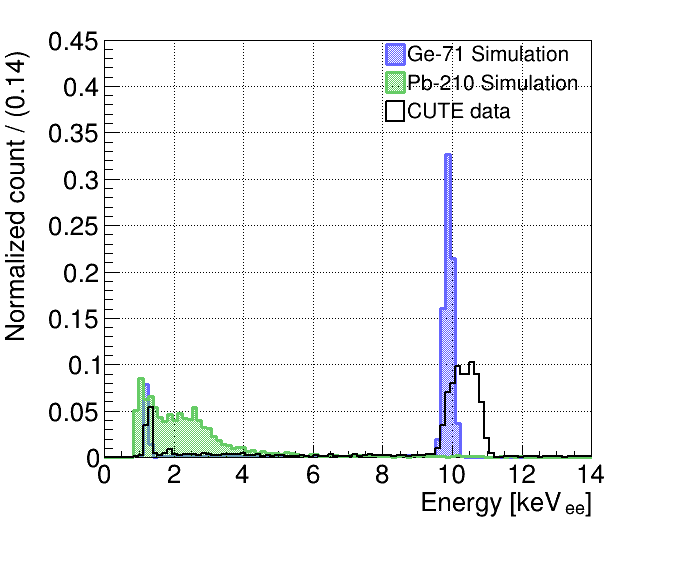

In [19]:
bins_start, bins_end, nbins = 0, 14, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

plt = ROOplot(_xlabel="Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.45)

plt.createHist(df['Ge']['calib_PTOFamps'][df['Ge']['cut']], bins_start, bins_end, nbins, width = 3, color=ROOT.kBlue-7, fillstyle=3001, scale=sum(df['K']['cut']), label="Ge-71 Simulation")
plt.createHist(df['Pb']['calib_PTOFamps'][df['Pb']['cut']], bins_start, bins_end, nbins, width = 3, color=ROOT.kGreen-6, fillstyle=3001, scale=sum(df['Pb']['cut']), label="Pb-210 Simulation")
plt.createHist(df['data']['calib_PTOFamps'][df['data']['cut']], bins_start, bins_end, nbins, width = 2, color=ROOT.kBlack, scale=sum(df['data']['cut']), label="CUTE data")

graphs = plt.getGraphs()
plt.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.55, 0.78, 0.85, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.SetTextSize(0.04)
legend.SetEntrySeparation(0.01)
legend.SetMargin(0.12)

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


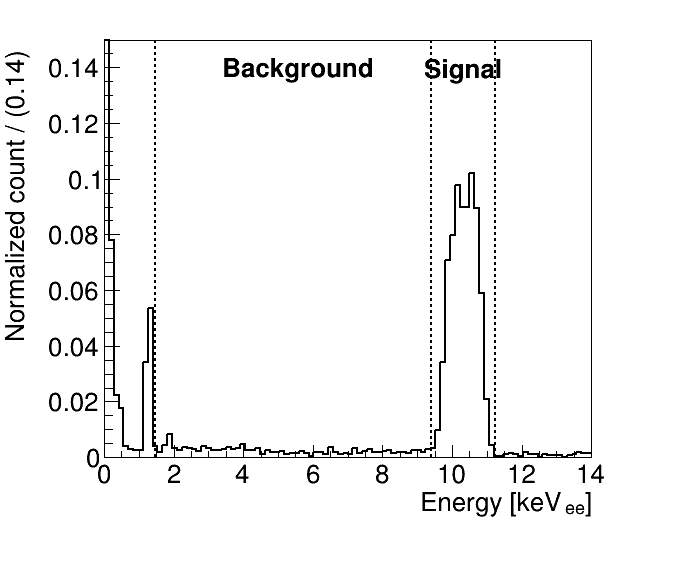

In [65]:
bins_start, bins_end, nbins = 0, 14, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

plt = ROOplot(_xlabel="Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.15)

plt.createHist(df['data']['calib_PTOFamps'], bins_start, bins_end, nbins, width = 2, color=ROOT.kBlack, label="CUTE data", scale = sum(df['data']['cut']))

graphs = plt.getGraphs()
plt.draw("HIST", "HIST ", grid=False)

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)

latex.DrawLatex(0.61, 0.9, "Signal")
latex.DrawLatex(0.32, 0.9, "Background")

line1 = ROOT.TLine(bounds['data']['K']['upper'], 0, bounds['data']['K']['upper'], 0.15)
line1.SetLineColor(ROOT.kBlack)
line1.SetLineStyle(2)
line1.SetLineWidth(2)
line1.Draw("same")

line2 = ROOT.TLine(bounds['data']['K']['lower'], 0, bounds['data']['K']['lower'], 0.15)
line2.SetLineColor(ROOT.kBlack)
line2.SetLineStyle(2)
line2.SetLineWidth(2)
line2.Draw("same")

line3 = ROOT.TLine(bounds['data']['L']['upper'], 0, bounds['data']['L']['upper'], 0.15)
line3.SetLineColor(ROOT.kBlack)
line3.SetLineStyle(2)
line3.SetLineWidth(2)
line3.Draw("same")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


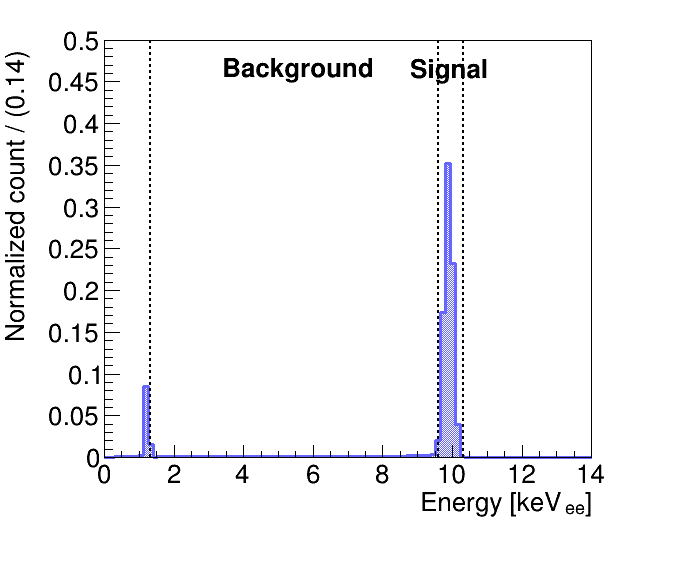

In [70]:
bins_start, bins_end, nbins = 0, 14, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

plt = ROOplot(_xlabel="Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.5)

plt.createHist(df['Ge']['calib_PTOFamps'], bins_start, bins_end, nbins, width = 3, color=ROOT.kBlue-7, fillstyle=3001, scale=sum(df['Ge']['cut']), label="Ge-71 Simulation")

graphs = plt.getGraphs()
plt.draw("HIST", "HIST ", grid=False)

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)

latex.DrawLatex(0.59, 0.9, "Signal")
latex.DrawLatex(0.32, 0.9, "Background")

line1 = ROOT.TLine(bounds['sim']['K']['upper'], 0, bounds['sim']['K']['upper'], 0.5)
line1.SetLineColor(ROOT.kBlack)
line1.SetLineStyle(2)
line1.SetLineWidth(2)
line1.Draw("same")

line2 = ROOT.TLine(bounds['sim']['K']['lower'], 0, bounds['sim']['K']['lower'], 0.5)
line2.SetLineColor(ROOT.kBlack)
line2.SetLineStyle(2)
line2.SetLineWidth(2)
line2.Draw("same")

line3 = ROOT.TLine(bounds['sim']['L']['upper'], 0, bounds['sim']['L']['upper'], 0.5)
line3.SetLineColor(ROOT.kBlack)
line3.SetLineStyle(2)
line3.SetLineWidth(2)
line3.Draw("same")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


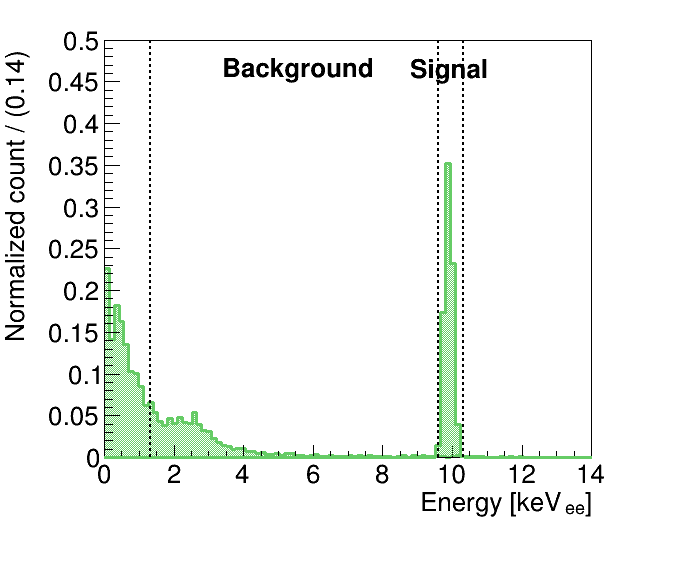

In [72]:
bins_start, bins_end, nbins = 0, 14, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

plt = ROOplot(_xlabel="Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.5)

plt.createHist(df['Pb']['calib_PTOFamps'], bins_start, bins_end, nbins, width = 3, color=ROOT.kGreen-6, fillstyle=3001, scale=sum(df['Pb']['cut']), label="Ge-71 Simulation")
plt.createHist(df['Ge']['calib_PTOFamps'][df['Ge']['Kshell_cut']], bins_start, bins_end, nbins, width = 3, color=ROOT.kGreen-6, fillstyle=3001, scale=sum(df['Ge']['cut']), label="Ge-71 Simulation")

graphs = plt.getGraphs()
plt.draw("HIST", "HIST ", grid=False)

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)

latex.DrawLatex(0.59, 0.9, "Signal")
latex.DrawLatex(0.32, 0.9, "Background")

line1 = ROOT.TLine(bounds['sim']['K']['upper'], 0, bounds['sim']['K']['upper'], 0.5)
line1.SetLineColor(ROOT.kBlack)
line1.SetLineStyle(2)
line1.SetLineWidth(2)
line1.Draw("same")

line2 = ROOT.TLine(bounds['sim']['K']['lower'], 0, bounds['sim']['K']['lower'], 0.5)
line2.SetLineColor(ROOT.kBlack)
line2.SetLineStyle(2)
line2.SetLineWidth(2)
line2.Draw("same")

line3 = ROOT.TLine(bounds['sim']['L']['upper'], 0, bounds['sim']['L']['upper'], 0.5)
line3.SetLineColor(ROOT.kBlack)
line3.SetLineStyle(2)
line3.SetLineWidth(2)
line3.Draw("same")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


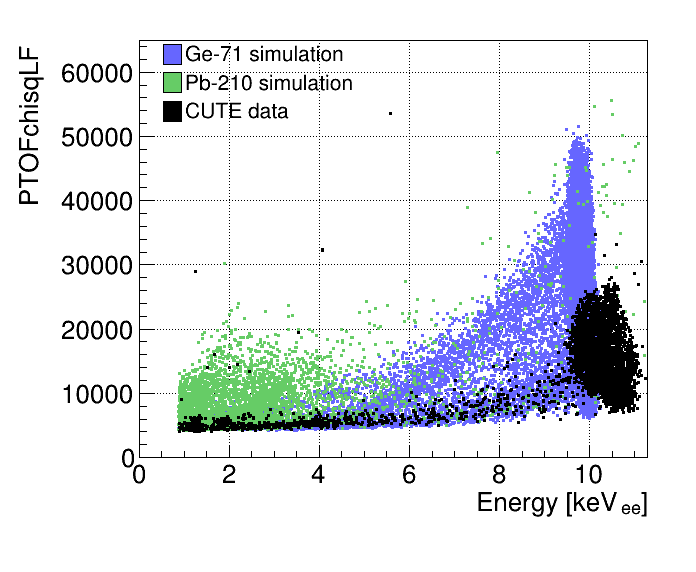

In [20]:
plt = ROOplot(_xlabel="Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]", _ylabel="PTOFchisqLF", _leftMargin=0.2, _rightMargin=0.07, _ylim=True, _ylow=0, _yhigh=65000)
plt.createScatter(df['Ge']['calib_PTOFamps'][df['Ge']['cut']], df['Ge']['PTOFchisqLF'][df['Ge']['cut']], color = ROOT.kBlue-7, size = 0.4, label = 'Ge-71 simulation')
plt.createScatter(df['Pb']['calib_PTOFamps'][df['Pb']['cut']], df['Pb']['PTOFchisqLF'][df['Pb']['cut']], color = ROOT.kGreen-6, size = 0.4, label = 'Pb-210 simulation')
plt.createScatter(df['data']['calib_PTOFamps'][df['data']['cut']], df['data']['PTOFchisqLF'][df['data']['cut']], color=ROOT.kBlack, size = 0.4, label = 'CUTE data')

graphs = plt.getGraphs()
plt.draw("AP", "P ", grid=True)

legend = ROOT.TLegend(0.23, 0.78, 0.53, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.SetTextSize(0.04)
legend.SetEntrySeparation(0.01)
legend.SetMargin(0.12)

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


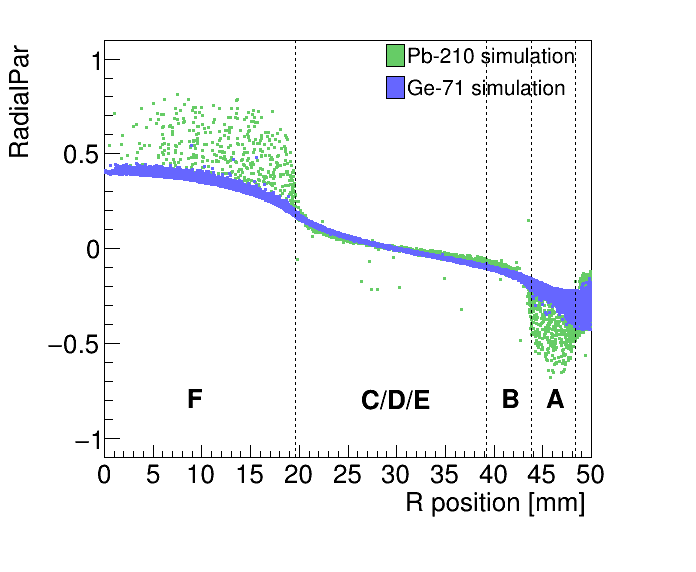

In [22]:
plt = ROOplot(_xlabel="R position [mm]", _ylabel="RadialPar", _xlim=True, _xlow=0, _xhigh=50, _ylim=True, _ylow=-1.1, _yhigh=1.1)
plt.createScatter(df['Pb']['R'][df['Pb']['cut']]*1e3, df['Pb']['RadialPar'][df['Pb']['cut']], color = ROOT.kGreen-6, size = 0.4, label = 'Pb-210 simulation')
plt.createScatter(df['Ge']['R'][df['Ge']['cut']]*1e3, df['Ge']['RadialPar'][df['Ge']['cut']], color = ROOT.kBlue-7, size = 0.4, label = 'Ge-71 simulation')

graphs = plt.getGraphs()
plt.draw("AP", "P ")

legend = ROOT.TLegend(0.55, 0.82, 0.85, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.SetTextSize(0.04)
legend.SetEntrySeparation(0.01)
legend.SetMargin(0.12)

legend.Draw()

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)

latex.DrawLatex(0.27, 0.32, "F")
latex.DrawLatex(0.52, 0.32, "C/D/E")
latex.DrawLatex(0.72, 0.32, "B")
latex.DrawLatex(0.785, 0.32, "A")

lineF = ROOT.TLine(19.592, -1.1, 19.592, 1.1)
lineF.SetLineColor(ROOT.kBlack)
lineF.SetLineStyle(2)
lineF.SetLineWidth(1)
lineF.Draw("same")

lineB = ROOT.TLine(39.192, -1.1, 39.192, 1.1)
lineB.SetLineColor(ROOT.kBlack)
lineB.SetLineStyle(2)
lineB.SetLineWidth(1)
lineB.Draw("same")

lineA = ROOT.TLine(43.818, -1.1, 43.818, 1.1)
lineA.SetLineColor(ROOT.kBlack)
lineA.SetLineStyle(2)
lineA.SetLineWidth(1)
lineA.Draw("same")

lineedge = ROOT.TLine(48.3, -1.1, 48.3, 1.1)
lineedge.SetLineColor(ROOT.kBlack)
lineedge.SetLineStyle(2)
lineedge.SetLineWidth(1)
lineedge.Draw("same")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


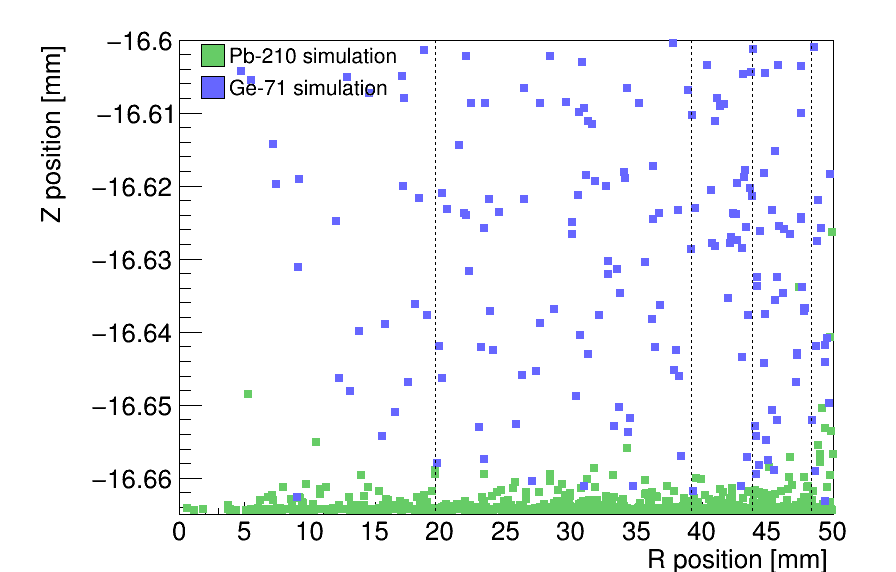

In [27]:
plt = ROOplot(900, 600, _xlabel="R position [mm]", _ylabel="Z position [mm]", _leftMargin=0.2, _rightMargin=0.07, _topMargin=0.07, _bottomMargin=0.1, 
                       _xlim=True, _xlow=0, _xhigh=50, _ylim=True, _ylow=-33.33/2, _yhigh=-16.6)

plt.createScatter(df['Pb']['R'][df['Pb']['cut']]*1e3, df['Pb']['Z'][df['Pb']['cut']]*1e3, color = ROOT.kGreen-6, size = 1, label = 'Pb-210 simulation')
plt.createScatter(df['Ge']['R'][df['Ge']['cut']]*1e3, df['Ge']['Z'][df['Ge']['cut']]*1e3, color = ROOT.kBlue-7, size = 1, label = 'Ge-71 simulation')

graphs = plt.getGraphs()
plt.draw("AP", "P ")

legend = ROOT.TLegend(0.22, 0.82, 0.52, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.SetTextSize(0.04)
legend.SetEntrySeparation(0.01)
legend.SetMargin(0.12)

legend.Draw()

lineF = ROOT.TLine(19.592, -33.33/2, 19.592, -16.6)
lineF.SetLineColor(ROOT.kBlack)
lineF.SetLineStyle(2)
lineF.SetLineWidth(1)
lineF.Draw("same")

lineB = ROOT.TLine(39.192, -33.33/2, 39.192, -16.6)
lineB.SetLineColor(ROOT.kBlack)
lineB.SetLineStyle(2)
lineB.SetLineWidth(1)
lineB.Draw("same")

lineA = ROOT.TLine(43.818, -33.33/2, 43.818, -16.6)
lineA.SetLineColor(ROOT.kBlack)
lineA.SetLineStyle(2)
lineA.SetLineWidth(1)
lineA.Draw("same")

lineedge = ROOT.TLine(48.3, -33.33/2, 48.3, -16.6)
lineedge.SetLineColor(ROOT.kBlack)
lineedge.SetLineStyle(2)
lineedge.SetLineWidth(1)
lineedge.Draw("same")

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


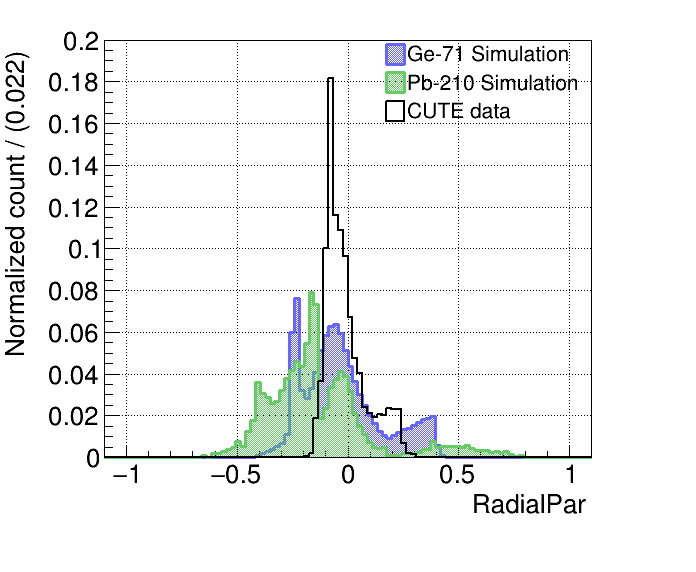

In [29]:
bins_start, bins_end, nbins = -1.1, 1.1, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="RadialPar", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.2)

hist.createHist(df['Ge']['RadialPar'][df['Ge']['cut']], bins_start, bins_end, nbins, width = 3, fillstyle=3001, color=ROOT.kBlue-7, scale=sum(df['Ge']['cut']), label="Ge-71 Simulation")
hist.createHist(df['Pb']['RadialPar'][df['Pb']['cut']], bins_start, bins_end, nbins, width = 3, fillstyle=3001, color=ROOT.kGreen-6, scale=sum(df['Pb']['cut']), label="Pb-210 Simulation")
hist.createHist(df['data']['RadialPar'][df['data']['cut']], bins_start, bins_end, nbins, width = 2, color=ROOT.kBlack, scale=sum(df['data']['cut']), label="CUTE data")

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.55, 0.78, 0.85, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.SetTextSize(0.04)
legend.SetEntrySeparation(0.01)
legend.SetMargin(0.12)

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


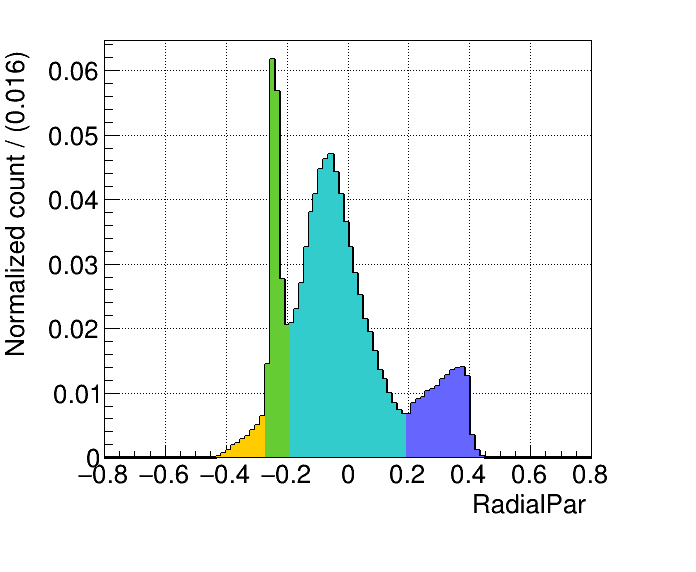

In [30]:
bins_start, bins_end, nbins = -0.8, 0.8, 100
bin_edges = np.linspace(bins_start, bins_end, nbins + 1)
binwidth = np.round((bins_end - bins_start) / nbins, 3)

plt = ROOplot(_xlabel="RadialPar", _ylabel="Normalized count / (" + str(binwidth) + ")")

plt.createHist(df['Ge']['RadialPar'][df['Ge']['cut']], bins_start, bins_end, nbins, width = 3, color=ROOT.kBlack, scale=sum(df['Ge']['cut']))

cut = (df['Ge']['cut']) & (df['Ge']['RadialPar'] < bin_edges[33])
plt.createHist(df['Ge']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kOrange, scale=sum(df['Ge']['cut']))

cut = (df['Ge']['cut']) & (df['Ge']['RadialPar'] >= bin_edges[33]) & (df['Ge']['RadialPar'] < bin_edges[38])
plt.createHist(df['Ge']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kSpring-5, scale=sum(df['Ge']['cut']))

cut = (df['Ge']['cut']) & (df['Ge']['RadialPar'] >= bin_edges[38]) & (df['Ge']['RadialPar'] < bin_edges[62])
plt.createHist(df['Ge']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kCyan-3, scale=sum(df['Ge']['cut']))

cut = (df['Ge']['cut']) & (df['Ge']['RadialPar'] >= bin_edges[62])
plt.createHist(df['Ge']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kBlue-7, scale=sum(df['Ge']['cut']))

graphs = hist.getGraphs()
plt.draw("HIST", "HIST ", grid=True)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


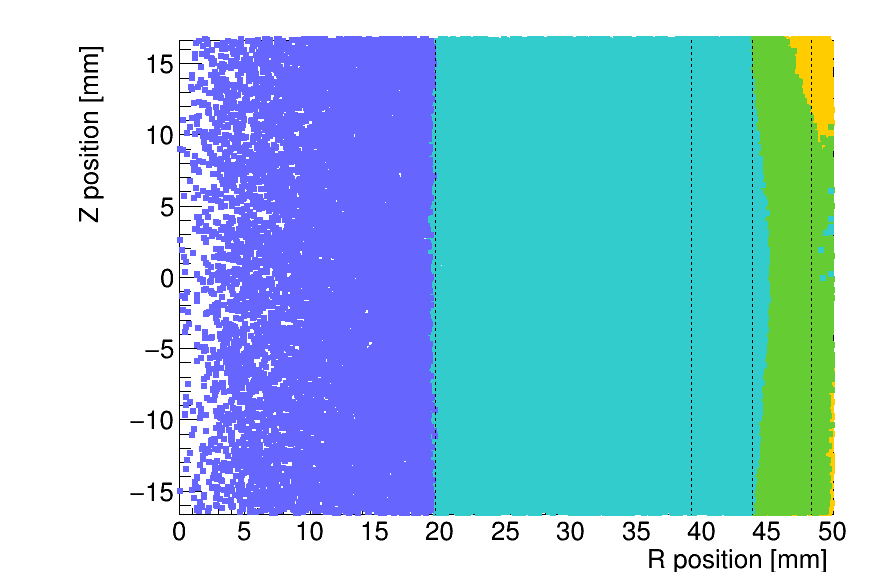

In [32]:
plt = ROOplot(900, 600, _xlabel="R position [mm]", _ylabel="Z position [mm]", _leftMargin=0.2, _rightMargin=0.07, _topMargin=0.07, _bottomMargin=0.1, 
                       _xlim=True, _xlow=0, _xhigh=50, _ylim=True, _ylow=-33.33/2, _yhigh=33.33/2)

cut = (df['Ge']['cut']) & (df['Ge']['RadialPar'] < bin_edges[33])
plt.createScatter(df['Ge']['R'][cut]*1e3, df['Ge']['Z'][cut]*1e3, color = ROOT.kOrange, size = 0.8)

cut = (df['Ge']['cut']) & (df['Ge']['RadialPar'] >= bin_edges[33]) & (df['Ge']['RadialPar'] < bin_edges[38])
plt.createScatter(df['Ge']['R'][cut]*1e3, df['Ge']['Z'][cut]*1e3, color = ROOT.kSpring-5, size = 0.8)

cut = (df['Ge']['cut']) & (df['Ge']['RadialPar'] >= bin_edges[38]) & (df['Ge']['RadialPar'] < bin_edges[62])
plt.createScatter(df['Ge']['R'][cut]*1e3, df['Ge']['Z'][cut]*1e3, color = ROOT.kCyan-3, size = 0.8)

cut = (df['Ge']['cut']) & (df['Ge']['RadialPar'] >= bin_edges[62])
plt.createScatter(df['Ge']['R'][cut]*1e3, df['Ge']['Z'][cut]*1e3, color = ROOT.kBlue-7, size = 0.8)
plt.draw("AP", "P ")

lineF = ROOT.TLine(19.592, -33.33/2, 19.592, 33.33/2)
lineF.SetLineColor(ROOT.kBlack)
lineF.SetLineStyle(2)
lineF.SetLineWidth(1)
lineF.Draw("same")

lineB = ROOT.TLine(39.192, -33.33/2, 39.192, 33.33/2)
lineB.SetLineColor(ROOT.kBlack)
lineB.SetLineStyle(2)
lineB.SetLineWidth(1)
lineB.Draw("same")

lineA = ROOT.TLine(43.818, -33.33/2, 43.818, 33.33/2)
lineA.SetLineColor(ROOT.kBlack)
lineA.SetLineStyle(2)
lineA.SetLineWidth(1)
lineA.Draw("same")

lineedge = ROOT.TLine(48.3, -33.33/2, 48.3, 33.33/2)
lineedge.SetLineColor(ROOT.kBlack)
lineedge.SetLineStyle(2)
lineedge.SetLineWidth(1)
lineedge.Draw("same")

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


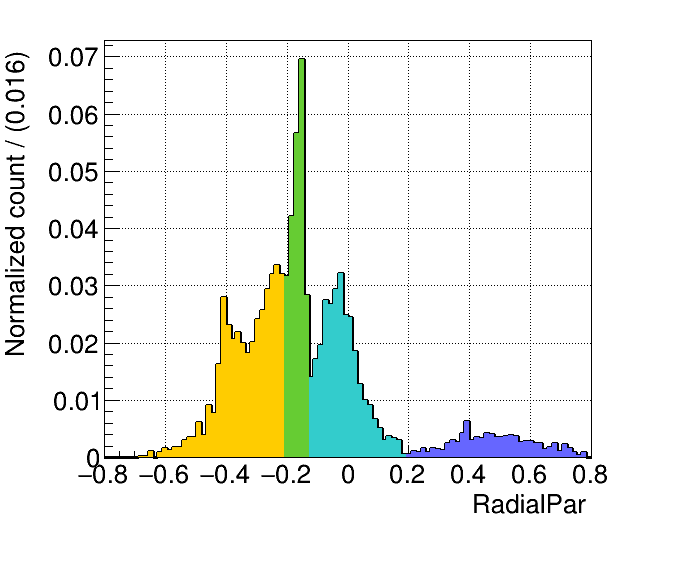

In [33]:
bins_start, bins_end, nbins = -0.8, 0.8, 100
bin_edges = np.linspace(bins_start, bins_end, nbins + 1)
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="RadialPar", _ylabel="Normalized count / (" + str(binwidth) + ")")

hist.createHist(df['Pb']['RadialPar'][df['Pb']['cut']], bins_start, bins_end, nbins, width = 3, color=ROOT.kBlack, scale=sum(df['Pb']['cut']))

cut = (df['Pb']['cut']) & (df['Pb']['RadialPar'] < bin_edges[37])
hist.createHist(df['Pb']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kOrange, scale=sum(df['Pb']['cut']))

cut = (df['Pb']['cut']) & (df['Pb']['RadialPar'] >= bin_edges[37]) & (df['Pb']['RadialPar'] < bin_edges[42])
hist.createHist(df['Pb']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kSpring-5, scale=sum(df['Pb']['cut']))

cut = (df['Pb']['cut']) & (df['Pb']['RadialPar'] >= bin_edges[42]) & (df['Pb']['RadialPar'] < bin_edges[62])
hist.createHist(df['Pb']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kCyan-3, scale=sum(df['Pb']['cut']))

cut = (df['Pb']['cut']) & (df['Pb']['RadialPar'] >= bin_edges[62])
hist.createHist(df['Pb']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kBlue-7, scale=sum(df['Pb']['cut']))

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


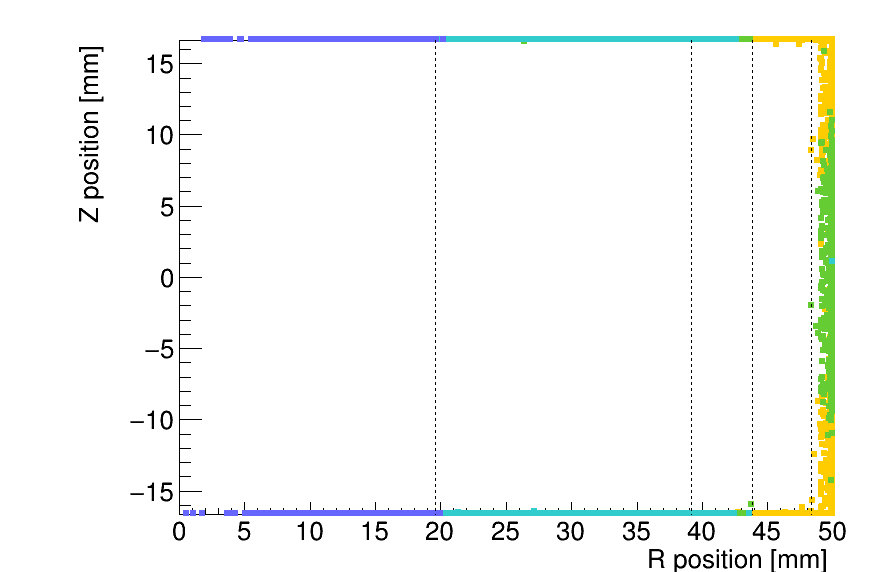

In [34]:
plt = ROOplot(900, 600, _xlabel="R position [mm]", _ylabel="Z position [mm]", _leftMargin=0.2, _rightMargin=0.07, _topMargin=0.07, _bottomMargin=0.1, 
                       _xlim=True, _xlow=0, _xhigh=50, _ylim=True, _ylow=-33.33/2, _yhigh=33.33/2)

cut = (df['Pb']['RadialPar'] < bin_edges[37]) & (df['Pb']['cut'])
plt.createScatter(df['Pb']['R'][cut]*1e3, df['Pb']['Z'][cut]*1e3, color = ROOT.kOrange, size = 0.8)

cut = (df['Pb']['RadialPar'] >= bin_edges[37]) & (df['Pb']['RadialPar'] < bin_edges[42]) & (df['Pb']['cut'])
plt.createScatter(df['Pb']['R'][cut]*1e3, df['Pb']['Z'][cut]*1e3, color = ROOT.kSpring-5, size = 0.8)

cut = (df['Pb']['RadialPar'] >= bin_edges[42]) & (df['Pb']['RadialPar'] < bin_edges[62]) & (df['Pb']['cut'])
plt.createScatter(df['Pb']['R'][cut]*1e3, df['Pb']['Z'][cut]*1e3, color = ROOT.kCyan-3, size = 0.8)

cut = (df['Pb']['RadialPar'] >= bin_edges[62]) & (df['Pb']['cut'])
plt.createScatter(df['Pb']['R'][cut]*1e3, df['Pb']['Z'][cut]*1e3, color = ROOT.kBlue-7, size = 0.8)
plt.draw("AP", "P ")

lineF = ROOT.TLine(19.592, -33.33/2, 19.592, 33.33/2)
lineF.SetLineColor(ROOT.kBlack)
lineF.SetLineStyle(2)
lineF.SetLineWidth(1)
lineF.Draw("same")

lineB = ROOT.TLine(39.192, -33.33/2, 39.192, 33.33/2)
lineB.SetLineColor(ROOT.kBlack)
lineB.SetLineStyle(2)
lineB.SetLineWidth(1)
lineB.Draw("same")

lineA = ROOT.TLine(43.818, -33.33/2, 43.818, 33.33/2)
lineA.SetLineColor(ROOT.kBlack)
lineA.SetLineStyle(2)
lineA.SetLineWidth(1)
lineA.Draw("same")

lineedge = ROOT.TLine(48.3, -33.33/2, 48.3, 33.33/2)
lineedge.SetLineColor(ROOT.kBlack)
lineedge.SetLineStyle(2)
lineedge.SetLineWidth(1)
lineedge.Draw("same")

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


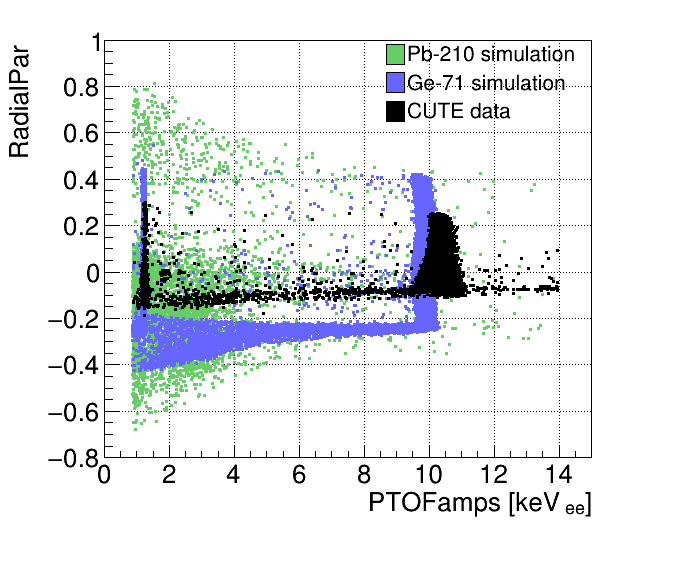

In [37]:
plt = ROOplot(_xlabel="PTOFamps [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]", _ylabel="RadialPar", _xlim=True, _xlow=0, _xhigh=15, _ylim=True, _ylow=-0.8, _yhigh=1)
plt.createScatter(df['Pb']['calib_PTOFamps'][df['Pb']['cut']], df['Pb']['RadialPar'][df['Pb']['cut']], color = ROOT.kGreen-6, label = 'Pb-210 simulation', size = 0.4)
plt.createScatter(df['Ge']['calib_PTOFamps'][df['Ge']['cut']], df['Ge']['RadialPar'][df['Ge']['cut']], color = ROOT.kBlue-7, label = 'Ge-71 simulation', size = 0.4)
plt.createScatter(df['data']['calib_PTOFamps'][df['data']['cut']], df['data']['RadialPar'][df['data']['cut']], color = ROOT.kBlack, label = 'CUTE data', size = 0.4)
plt.draw("AP", "P ", grid=True)
graphs = plt.getGraphs()

legend = ROOT.TLegend(0.55, 0.78, 0.85, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.SetTextSize(0.04)
legend.SetEntrySeparation(0.01)
legend.SetMargin(0.12)

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


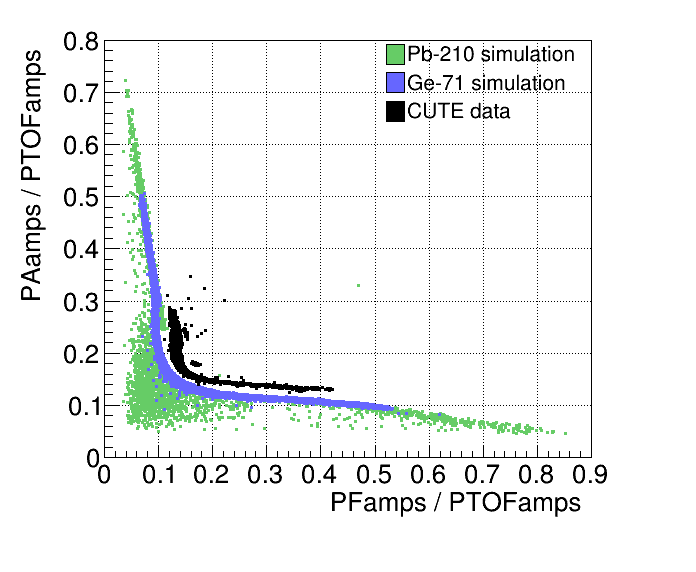

In [52]:
plt = ROOplot(700, 600, _xlabel="PFamps / PTOFamps", _ylabel="PAamps / PTOFamps", _xlim=True, _xlow=0, _xhigh=0.9, _ylim=True, _ylow=0, _yhigh=0.8)

plt.createScatter(df['Pb']['F'][df['Pb']['cut']], df['Pb']['A'][df['Pb']['cut']], color = ROOT.kGreen-6, label = "Pb-210 simulation", size=0.4)
plt.createScatter(df['Ge']['F'][df['Ge']['cut']], df['Ge']['A'][df['Ge']['cut']], color = ROOT.kBlue-7, label = "Ge-71 simulation", size=0.4)
plt.createScatter(df['data']['F'][df['data']['cut']], df['data']['A'][df['data']['cut']], color = ROOT.kBlack, label = "CUTE data", size=0.4)

plt.draw("AP", "P ", grid=True)

graphs = plt.getGraphs()

legend = ROOT.TLegend(0.55, 0.78, 0.85, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.SetTextSize(0.04)
legend.SetEntrySeparation(0.01)
legend.SetMargin(0.12)

legend.Draw()

In [40]:
cut = 'cut'
sample_names = ['Ge', 'Pb', 'data']
thresholds = np.arange(-1, 1, 0.01)

count = {s: sum(df[s][cut]) for s in sample_names}
passed = {s: np.array([sum(df[s][cut] & (df[s]['RadialPar'] > threshold)) for threshold in thresholds]) for s in sample_names}

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_eff


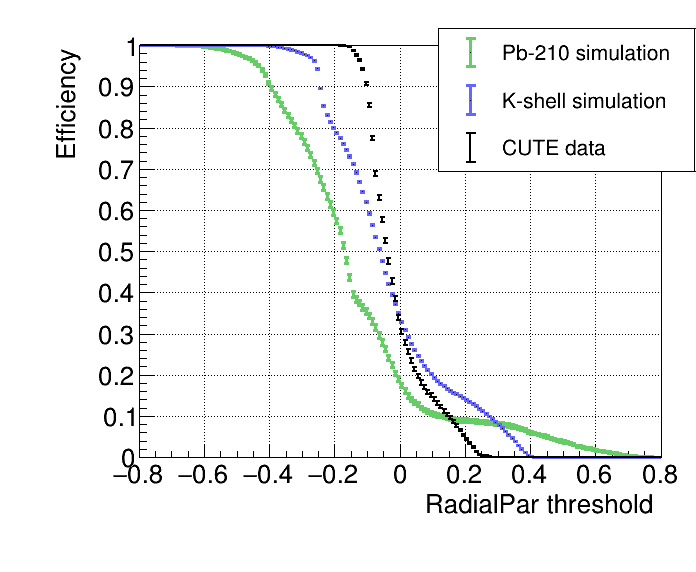

In [43]:
c = ROOT.TCanvas("c_eff", "", 700, 600)
bins_start = thresholds[0] - np.diff(thresholds)[0]/2
bins_end = thresholds[-1] - np.diff(thresholds)[0]/2
nbins = len(thresholds)
bindiff = np.round((bins_end - bins_start) / nbins, 2)

eff = {s: ROOT.TEfficiency("eff_sim", " ; ; ", nbins, bins_start, bins_end) for s in sample_names}

for s in sample_names:
    for i, (t, p) in enumerate(zip(thresholds, passed[s])):
        eff[s].SetTotalEvents(i+1, int(count[s]))
        eff[s].SetPassedEvents(i+1, int(p))

g1 = eff['Pb'].CreateGraph()
for i in range(g1.GetN()):
    g1.SetPointEXlow(i, 0)
    g1.SetPointEXhigh(i, 0)
    
g1.SetLineColor(ROOT.kGreen-6)
g1.SetLineWidth(3)
g1.GetXaxis().SetTitle("RadialPar threshold")
g1.GetYaxis().SetTitle(f"Efficiency")
g1.GetXaxis().SetLabelSize(0.05)
g1.GetYaxis().SetLabelSize(0.05)
g1.GetXaxis().SetTitleSize(0.05)
g1.GetYaxis().SetTitleSize(0.05)
g1.SetMaximum(1)
g1.SetMinimum(0)

g2 = eff['Ge'].CreateGraph()
for i in range(g2.GetN()):
    g2.SetPointEXlow(i, 0)
    g2.SetPointEXhigh(i, 0)

g2.SetLineColor(ROOT.kBlue-7)
g2.SetLineWidth(3)

g3 = eff['data'].CreateGraph()
for i in range(g2.GetN()):
    g3.SetPointEXlow(i, 0)
    g3.SetPointEXhigh(i, 0)
    
g3.SetLineColor(ROOT.kBlack)
g3.SetLineWidth(2)

g1.GetXaxis().SetLimits(-0.8, 0.8)

g1.Draw("AP")
g2.Draw("P SAME")
g3.Draw("P SAME")

legend = ROOT.TLegend(0.63, 0.7, 1, 0.95)
legend.SetBorderSize(1)
legend.SetFillStyle(1001)
legend.SetFillColor(ROOT.kWhite)
legend.AddEntry(g1, "Pb-210 simulation", "ep")
legend.AddEntry(g2, "K-shell simulation", "ep")
legend.AddEntry(g3, "CUTE data", "ep")
legend.SetTextSize(0.04)

legend.Draw()
c.SetLeftMargin(0.2)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetGrid(1, 1)

c.Draw()

In [45]:
thresholds = np.arange(-0.8, 0.8, 0.01)
signal_count = {s: sum(df[s]['Kshell_cut']) for s in ['Ge', 'data']}
BG_count = {s: sum(df[s]['BG_cut']) for s in ['Ge', 'Pb', 'data']}
signal_passed = {s: np.array([sum(df[s]['Kshell_cut'] & (df[s]['RadialPar'] > threshold)) for threshold in thresholds]) for s in ['Ge', 'data']}
BG_passed = {s: np.array([sum(df[s]['BG_cut'] & (df[s]['RadialPar'] > threshold)) for threshold in thresholds]) for s in ['Ge', 'Pb', 'data']}

In [46]:
def getEfficiency(total, passed):
    eff = ROOT.TEfficiency("eff", "eff", 1, 0., 1.)
    eff.SetTotalEvents(1, int(total))
    eff.SetPassedEvents(1, int(passed))

    efficiency = eff.GetEfficiency(1)
    efficiency_ErrorLow = eff.GetEfficiencyErrorLow(1)
    efficiency_ErrorUp = eff.GetEfficiencyErrorUp(1)

    return efficiency, efficiency_ErrorLow, efficiency_ErrorUp

In [47]:
for i in range(len(thresholds)):

    signal_eff = {s: getEfficiency(signal_count[s], signal_passed[s][i]) for s in ['Ge', 'data']}
    BG_eff = {s: getEfficiency(BG_count[s], BG_passed[s][i]) for s in ['Ge', 'Pb', 'data']}

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_eff


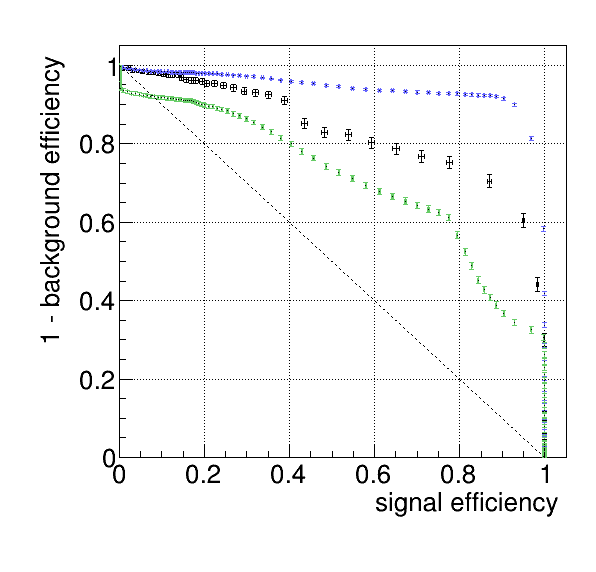

In [51]:
c = ROOT.TCanvas("c_eff", "", 600, 600)
g1 = ROOT.TGraphAsymmErrors()
g2 = ROOT.TGraphAsymmErrors()
g3 = ROOT.TGraphAsymmErrors()

point = 0

for i in range(len(thresholds)):

    signal_eff = {s: getEfficiency(signal_count[s], signal_passed[s][i]) for s in ['Ge', 'data']}
    BG_eff = {s: getEfficiency(BG_count[s], BG_passed[s][i]) for s in ['Ge', 'Pb', 'data']}

    g1.SetPoint(point, signal_eff['data'][0], 1-BG_eff['data'][0])
    g1.SetPointError(point, signal_eff['data'][1], signal_eff['data'][2], BG_eff['data'][2], BG_eff['data'][1])
    g2.SetPoint(point, signal_eff['Ge'][0], 1-BG_eff['Ge'][0])
    g2.SetPointError(point, signal_eff['Ge'][1], signal_eff['Ge'][2], BG_eff['Ge'][2], BG_eff['Ge'][1])
    g3.SetPoint(point, signal_eff['Ge'][0], 1-BG_eff['Pb'][0])
    g3.SetPointError(point, signal_eff['Ge'][1], signal_eff['Ge'][2], BG_eff['Pb'][2], BG_eff['Pb'][1])

    point += 1

g1.SetLineColor(ROOT.kBlack)
g1.SetLineWidth(1)
g2.SetLineColor(ROOT.kBlue-7)
g2.SetLineWidth(1)
g3.SetLineColor(ROOT.kGreen-6)
g3.SetLineWidth(1)
g1.GetXaxis().SetTitle("signal efficiency")
g1.GetYaxis().SetTitle(f"1 - background efficiency")
g1.GetXaxis().SetLabelSize(0.05)
g1.GetYaxis().SetLabelSize(0.05)
g1.GetXaxis().SetTitleSize(0.05)
g1.GetYaxis().SetTitleSize(0.05)
g1.SetMaximum(1.05)
g1.SetMinimum(0)
g1.GetXaxis().SetLimits(0, 1.05)

g1.Draw("AP")
g2.Draw("P same")
g3.Draw("P same")

line = ROOT.TLine(0, 1, 1, 0)
line.SetLineColor(ROOT.kBlack)
line.SetLineStyle(2)
line.SetLineWidth(1)
line.Draw("same")

c.SetLeftMargin(0.2)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetGrid(1, 1)

c.Draw()